<a href="https://colab.research.google.com/github/QuynhTram51/KLTN-analysis-painpoints/blob/main/%5BKLTN%5D_CH%E1%BA%A0Y_dataset_deal_%2B_prospect_CRM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## I. DATA PREPARATION
Bước khởi đầu của quy trình phân tích dữ liệu khám phá (EDA) yêu cầu một cuộc kiểm toán cấu trúc đối với ba kho lưu trữ dữ liệu cốt lõi được trích xuất từ Lark Base CRM của CloudAZ: df_prospect (Nhật ký hành động tương tác đầu phễu), df_deal (Dòng chảy giao dịch thương mại cuối phễu), và df_masteraccount (Hồ sơ thực thể doanh nghiệp trung tâm). Việc thấu hiểu bức tranh tổng quan về phân bổ khối lượng công việc bán hàng, các phân khúc ngành nghề mục tiêu và trạng thái đóng đơn ban đầu là điều kiện kiên quyết để thiết lập một đường cơ sở vận hành.

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**[MÔ HÌNH STAR SCHEMA: 3 DATASETS]**

df_masteraccount (Trung tâm dữ liệu tĩnh của Doanh nghiệp)

df_prospect (Nhật ký hành động, tương tác đầu phễu)

df_deal (Dòng chảy tài chính và kết quả chuyển đổi cuối phễu)

In [ ]:
# Step 2: Import pandas and load datasets
import pandas as pd
deal_path = '/content/drive/MyDrive/<cá nhân> K61 DB KLTN Quỳnh Trâm/dataset crm 265/all deals.csv'
prospect_path = '/content/drive/MyDrive/<cá nhân> K61 DB KLTN Quỳnh Trâm/dataset crm 265/all prospect.csv'
master_path = '/content/drive/MyDrive/<cá nhân> K61 DB KLTN Quỳnh Trâm/dataset crm 265/master account.csv'

df_prospect = pd.read_csv(prospect_path)
df_deal = pd.read_csv(deal_path)
df_masteraccount = pd.read_csv(master_path)

print("Prospect Data:")
display(df_prospect.head())

print("Deal Data:")
display(df_deal.head())

print("Master Account Data:")
display(df_masteraccount.head())

Prospect Data:


,Prospect ID,Sales Phụ trách,Source deal,Trạng thái (Status),PIC Phía khách,Chức vụ,Ngành nghề,Tên công ty,Mã số thuế,Domain công ty,...,Chữ,Xuất thông tin danh thiếp,Ngày prospect,Account,Prospect Name,Nội dung Email,Giới tính,Vị trí,Trạng thái gửi mail,Trâm gửi mail
0,87,Hoàng Hà Trang,Selfsource,Prospecting,Anh Anh Han,BOD,Logistics/Transportation Tech,Nhất Tín Logistics,'0312803588,http://ntlogistics.vn,...,NaN,NaN,24/03/2026,NaN,NaN,"Dear ,\n\nEm là Hoàng Hà Trang từ công ty Clou...",NaN,Hoàng Hà Trang,NaN,Gửi
1,88,Hoàng Hà Trang,Selfsource,Prospecting,Anh Ngon Pham,CEO,Logistics/Transportation Tech,Ahamove,'0313506115,http://ahamove.com,...,NaN,NaN,24/03/2026,NaN,NaN,"Dear Anh,\n\nEm là Hoàng Hà Trang từ công ty C...",Anh,Hoàng Hà Trang,Gửi mail thành công,Gửi
2,89,Hoàng Hà Trang,Selfsource,Prospecting,Anh Tuan Pham,Director of Operations,Logistics/Transportation Tech,U&I Logistics,3700492666,http://unilogistics.vn,...,NaN,NaN,24/03/2026,NaN,NaN,"Dear ,\n\nEm là Hoàng Hà Trang từ công ty Clou...",NaN,Hoàng Hà Trang,NaN,Gửi
3,90,Hoàng Hà Trang,Selfsource,Prospecting,Anh Thang Tran,Managing Director,Logistics/Transportation Tech,Vantage Logistics,0302802063,http://vlc.com.vn,...,NaN,NaN,24/03/2026,NaN,NaN,"Dear ,\n\nEm là Hoàng Hà Trang từ công ty Clou...",NaN,Hoàng Hà Trang,NaN,Gửi
4,91,Hoàng Hà Trang,Selfsource,Prospecting,Anh Chung,CEO,Logistics/Transportation Tech,Phaata,0314667281,http://phaata.com,...,NaN,NaN,24/03/2026,NaN,NaN,"Dear ,\n\nEm là Hoàng Hà Trang từ công ty Clou...",NaN,Hoàng Hà Trang,NaN,Gửi


Deal Data:


,Deal ID,Deal Name,ReportingQuarter,Status,Deal Amount,Sales Owner,Industry,Deal Type,Date Created,Closed Date,...,Demand,Estimated time win deal,Order Type,Sale Leader,Contract model,Product of interest,Account,Contact,Won Date,Lost Date
0,GCP_Deal_150,BDS Phúc Anh,Quý 2 - 2026,Won,200.0,Hoàng Hà Trang,NaN,Resell,2026/04/22 15:58,2026/05/19,...,NaN,NaN,NaN,Phạm Tiến Thiêm,NaN,GMAP,GCP_Acc_126,GCP_Con_040,2026/05/19 10:27,NaN
1,GCP_Deal_160,KEETAA,Quý 2 - 2026,Won,200.0,Hoàng Hà Trang,Food & Beverage,Resell,2026/05/14 14:10,NaN,...,NaN,2026/05/14,NaN,Phạm Tiến Thiêm,NaN,GCP,GCP_Acc_172,NaN,2026/05/14 14:10,NaN
2,GCP_Deal_002,BTMH (GCP),Quý 1 - 2026,Won,500.0,Hoàng Tuấn Dương,Retails,Resell,2026/02/06 13:51,2026/03/03,...,NaN,NaN,NaN,Phạm Tiến Thiêm,NaN,GCP,NaN,NaN,NaN,NaN
3,GCP_Deal_003,AITS (GMAP),Quý 1 - 2026,Pending,300.0,Hoàng Tuấn Dương,IT-Software,Resell,2026/02/06 13:50,NaN,...,NaN,NaN,NaN,Phạm Tiến Thiêm,NaN,GCP,GCP_Acc_031,NaN,NaN,NaN
4,GCP_Deal_004,A1 Consulting (GMAP),Quý 1 - 2026,Won,100.0,Hoàng Tuấn Dương,NaN,Resell,2026/02/10 11:45,NaN,...,NaN,NaN,NaN,Phạm Tiến Thiêm,NaN,GCP,NaN,NaN,NaN,NaN


Master Account Data:


,Account ID,Company Name,Domain Company,Tax Code,Address,Billing address,Industry,Source,Company Size,Sales Leader,...,Product of interest,Master Contact,All Deals,Create Deal,Create Contact,Create Prospect,Date Created,Prospect,Last Modified Date,Modified By
0,GCP_Acc_058,Coolmate,coolmate.me,0402172552,"Số 123 Dũng Sỹ Thanh Khê, Phường Thanh Khê, Th...",NaN,Ecommerce,Self-sourced,SMB,Phạm Tiến Thiêm,...,GCP,NaN,NaN,Create Deal,Create Contact,Create Prospect,2026/04/08 16:04,104.0,2026/04/24 10:33,Hoàng Hà Trang
1,GCP_Acc_059,Sendo,sendo.vn,0312776486,NaN,NaN,Ecommerce,Self-sourced,ENTERPRISE,Phạm Tiến Thiêm,...,GCP,NaN,NaN,Create Deal,Create Contact,Create Prospect,2026/04/08 16:11,105.0,2026/04/24 10:34,Hoàng Hà Trang
2,GCP_Acc_060,Pharmacity,pharmacity.vn,0311770883,NaN,NaN,Ecommerce,Self-sourced,Enterprise,Phạm Tiến Thiêm,...,GCP,NaN,NaN,Create Deal,Create Contact,Create Prospect,2026/04/08 16:16,106.0,2026/04/24 10:34,Hoàng Hà Trang
3,GCP_Acc_065,Lameco,lmc.vn,0109762951,NaN,NaN,Ecommerce,Self-sourced,Startup,Phạm Tiến Thiêm,...,GCP,NaN,NaN,Create Deal,Create Contact,Create Prospect,2026/04/08 16:32,107.0,2026/04/24 10:34,Hoàng Hà Trang
4,GCP_Acc_066,Ecomomi,ecomobi.com,0108109926,"Tầng 4, Tháp 2 Times Tower, số 35 đường Lê Văn...",NaN,Ecommerce,Self-sourced,Startup,Phạm Tiến Thiêm,...,GCP,NaN,NaN,Create Deal,Create Contact,Create Prospect,2026/04/08 16:39,108.0,2026/04/24 10:34,Hoàng Hà Trang


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


#II.  MARKET PROFILE & DATA HYGIENE

Nền tảng của một chiến lược tiếp cận dựa trên dữ liệu (data-driven strategy) nằm ở ba trụ cột chính của chất lượng dữ liệu: Mức độ đầy đủ (Completeness), Tính duy nhất (Uniqueness) và Tính hợp lệ (Validity). Việc hệ thống CRM tồn tại dữ liệu rác, trùng lặp hồ sơ hoặc khuyết thiếu thông tin liên lạc sẽ trực tiếp bẻ gãy các bộ lọc tự động và khiến Sales gửi các thông điệp sai lệch. Phân mục này tiến hành một cuộc kiểm toán sâu vào bảng df_masteraccount và df_prospect nhằm bóc tách tỷ lệ khuyết thiếu thông tin tĩnh của doanh nghiệp, phát hiện các bản ghi trùng lặp mã số thuế hoặc tên miền (Domain), từ đó định lượng mức độ tổn thương của hệ sinh thái dữ liệu CRM hiện tại.

## 1. Industry distribution

--- [MARKET ANALYSIS] Industry Distribution in Master Account ---
Industry: nan                       | Volume: 59   (29.80%)
Industry: Tourism                   | Volume: 21   (10.61%)
Industry: Ecommerce                 | Volume: 16   (8.08%)
Industry: Edtech                    | Volume: 13   (6.57%)
Industry: Technology                | Volume: 7    (3.54%)
Industry: EDTECH                    | Volume: 6    (3.03%)
Industry: Renewable Energy          | Volume: 6    (3.03%)
Industry: AI                        | Volume: 5    (2.53%)
Industry: Manufacturing             | Volume: 4    (2.02%)
Industry: Manufacturing & Automotiv | Volume: 4    (2.02%)
Industry: Finance & Banking         | Volume: 3    (1.52%)
Industry: Bank                      | Volume: 3    (1.52%)
Industry: Education                 | Volume: 3    (1.52%)
Industry: Technology - Software/Saa | Volume: 2    (1.01%)
Industry: Games                     | Volume: 2    (1.01%)
Industry: Real-Estate               | Volume: 2

/tmp/ipykernel_42426/2016721814.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.head(8).values, y=industry_counts.head(8).index, palette='Blues_r')


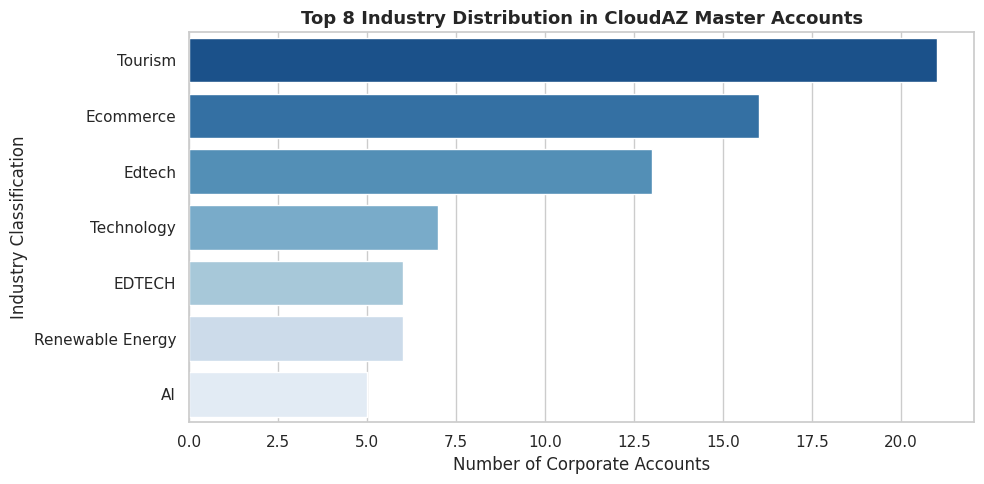

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns

sns.set_theme(style="whitegrid")

# Industry distribution
industry_counts = df_masteraccount['Industry'].value_counts(dropna=False)
industry_pct = df_masteraccount['Industry'].value_counts(normalize=True, dropna=False) * 100

print("--- [MARKET ANALYSIS] Industry Distribution in Master Account ---")
for ind in industry_counts.index:
    print(f"Industry: {str(ind)[:25]:<25} | Volume: {industry_counts[ind]:<4} ({industry_pct[ind]:.2f}%)")

# Visualization top 8 industries
plt.figure(figsize=(10, 5))
sns.barplot(x=industry_counts.head(8).values, y=industry_counts.head(8).index, palette='Blues_r')
plt.title('Top 8 Industry Distribution in CloudAZ Master Accounts', fontsize=13, fontweight='bold')
plt.xlabel('Number of Corporate Accounts')
plt.ylabel('Industry Classification')
plt.tight_layout()
plt.show()

=> The industry distribution suggests that CloudAZ primarily targets digitally intensive sectors such as Tourism, Ecommerce, and Edtech. However, inconsistencies in industry labeling (e.g., “Edtech” vs “EDTECH”) reveal underlying CRM data standardization issues, which may reduce the accuracy of segmentation and strategic reporting.

## 2. Sales workload


--- [OPERATIONAL QUALITY] Sales Workload Distribution (df_deal) ---
Sales Rep: Nguyễn Hoài Phương   | Assigned Deals: 46   (28.05%)
Sales Rep: Trần Hậu Nhân        | Assigned Deals: 40   (24.39%)
Sales Rep: Tăng Thuỳ Dương      | Assigned Deals: 27   (16.46%)
Sales Rep: Hoàng Tuấn Dương     | Assigned Deals: 17   (10.37%)
Sales Rep: Vũ Đức Nghĩa         | Assigned Deals: 16   (9.76%)
Sales Rep: Phạm Tiến Thiêm      | Assigned Deals: 9    (5.49%)
Sales Rep: Lê Đức Thành         | Assigned Deals: 6    (3.66%)
Sales Rep: Hoàng Hà Trang       | Assigned Deals: 2    (1.22%)
Sales Rep: Đậu Thị Quỳnh Trâm   | Assigned Deals: 1    (0.61%)


/tmp/ipykernel_42426/4116986037.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_workload_deal.values, y=sales_workload_deal.index, ax=ax[0], palette='viridis')
/tmp/ipykernel_42426/4116986037.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_workload_prospect.values, y=sales_workload_prospect.index, ax=ax[1], palette='magma')


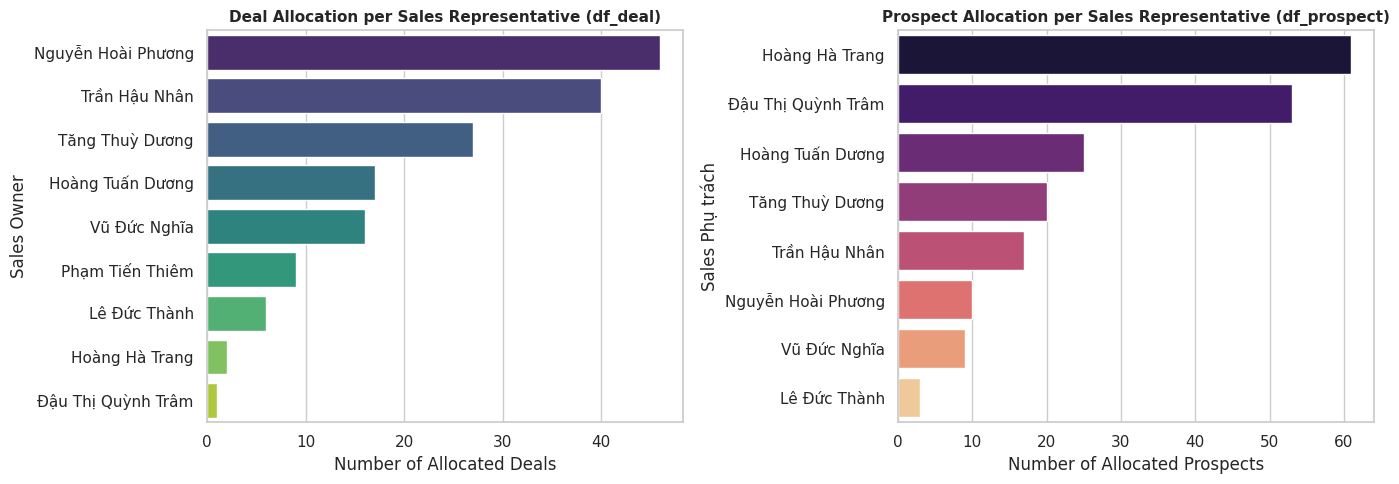

In [ ]:
# Define the heaviest workload owner
sales_workload_deal = df_deal['Sales Owner'].value_counts(dropna=False)
sales_workload_deal_pct = df_deal['Sales Owner'].value_counts(normalize=True, dropna=False) * 100

print("\n--- [OPERATIONAL QUALITY] Sales Workload Distribution (df_deal) ---")
for rep in sales_workload_deal.index:
    print(f"Sales Rep: {str(rep):<20} | Assigned Deals: {sales_workload_deal[rep]:<4} ({sales_workload_deal_pct[rep]:.2f}%)")

sales_workload_prospect = df_prospect['Sales Phụ trách'].value_counts(dropna=False)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=sales_workload_deal.values, y=sales_workload_deal.index, ax=ax[0], palette='viridis')
ax[0].set_title('Deal Allocation per Sales Representative (df_deal)', fontsize=11, fontweight='bold')
ax[0].set_xlabel('Number of Allocated Deals')

sns.barplot(x=sales_workload_prospect.values, y=sales_workload_prospect.index, ax=ax[1], palette='magma')
ax[1].set_title('Prospect Allocation per Sales Representative (df_prospect)', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Number of Allocated Prospects')

plt.tight_layout()
plt.show()

The charts reveal a severe imbalance and highly specialized division of labor within the sales team, where some reps act strictly as "closers" and others as "lead qualifiers." For instance, Nguyễn Hoài Phương manages the highest volume of active deals (over 45) but almost no prospects, whereas Hoàng Hà Trang and Đậu Thị Quỳnh Trâm heavily dominate prospect allocation (50–60+) with nearly zero active deals. This stark inverse relationship suggests an inefficient routing system or a lack of standardized pipeline handovers, which could easily bottleneck the conversion funnel.

## 3. Checking missing data in critical fields

--- [AUDIT REPORT 1] df_prospect Data Hygiene ---
              Field  Missing Count  Missing Rate (%)
        Source deal              0          0.000000
Trạng thái (Status)              0          0.000000
         Ngành nghề             50         25.252525
         Mã số thuế             80         40.404040
 Số lượng nhân viên            144         72.727273

--- [AUDIT REPORT 2] df_deal Data Hygiene ---
       Field  Missing Count  Missing Rate (%)
      Status              1          0.609756
 Deal Amount             18         10.975610
 Sales Owner              0          0.000000
    Industry             65         39.634146
Date Created              0          0.000000

--- [AUDIT REPORT 3] df_masteraccount Data Hygiene ---
       Field  Missing Count  Missing Rate (%)
Company Name             12          6.060606
    Tax Code             53         26.767677
    Industry             59         29.797980
      Source             48         24.242424
Company Size           

/tmp/ipykernel_42426/1363506509.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_master_hygiene, x='Field', y='Missing Rate (%)', palette='Reds_r')


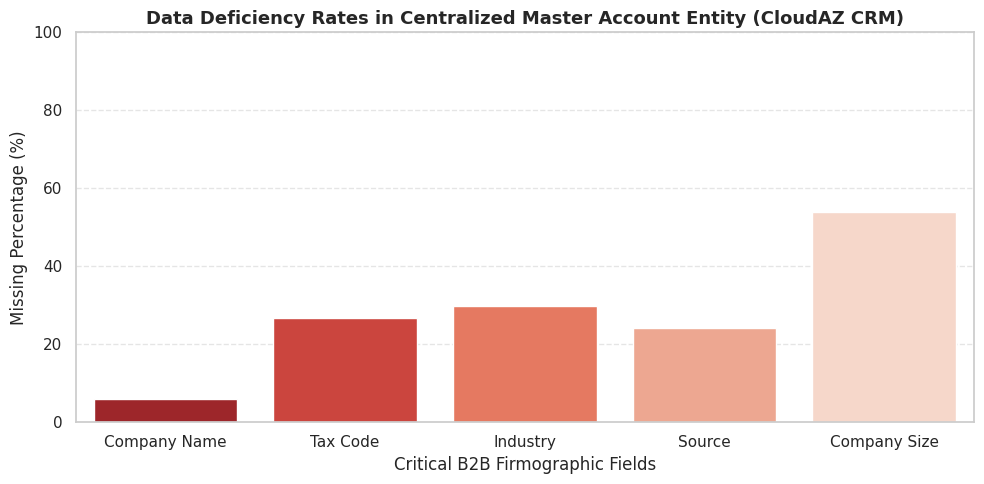

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define critical B2B qualification and operational fields within each specific entity
prospect_critical = ['Source deal', 'Trạng thái (Status)', 'Ngành nghề', 'Mã số thuế', 'Số lượng nhân viên']
deal_critical     = ['Status', 'Deal Amount', 'Sales Owner', 'Industry', 'Date Created']
master_critical   = ['Company Name', 'Tax Code', 'Industry', 'Source', 'Company Size']

# 1. Compute exact missing data volume and percentages
missing_prospect = df_prospect[prospect_critical].isnull().sum()
pct_prospect     = df_prospect[prospect_critical].isnull().mean() * 100

missing_deal     = df_deal[deal_critical].isnull().sum()
pct_deal         = df_deal[deal_critical].isnull().mean() * 100

missing_master   = df_masteraccount[master_critical].isnull().sum()
pct_master       = df_masteraccount[master_critical].isnull().mean() * 100

# 2. Structure the data audit reports into consolidated DataFrames
df_prospect_hygiene = pd.DataFrame({'Missing Count': missing_prospect, 'Missing Rate (%)': pct_prospect}).reset_index().rename(columns={'index': 'Field'})
df_deal_hygiene     = pd.DataFrame({'Missing Count': missing_deal, 'Missing Rate (%)': pct_deal}).reset_index().rename(columns={'index': 'Field'})
df_master_hygiene   = pd.DataFrame({'Missing Count': missing_master, 'Missing Rate (%)': pct_master}).reset_index().rename(columns={'index': 'Field'})

print("--- [AUDIT REPORT 1] df_prospect Data Hygiene ---")
print(df_prospect_hygiene.to_string(index=False))
print("\n--- [AUDIT REPORT 2] df_deal Data Hygiene ---")
print(df_deal_hygiene.to_string(index=False))
print("\n--- [AUDIT REPORT 3] df_masteraccount Data Hygiene ---")
print(df_master_hygiene.to_string(index=False))

# 3. Visualizing Data Sparsity across the central Master Account table
plt.figure(figsize=(10, 5))
sns.barplot(data=df_master_hygiene, x='Field', y='Missing Rate (%)', palette='Reds_r')
plt.title('Data Deficiency Rates in Centralized Master Account Entity (CloudAZ CRM)', fontsize=13, fontweight='bold')
plt.xlabel('Critical B2B Firmographic Fields')
plt.ylabel('Missing Percentage (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The chart highlights critical data deficiency gaps within CloudAZ's CRM, particularly for firmographic fields essential to B2B targeting, with "Company Size" missing more than 50% of its data. Other vital strategic attributes like "Industry", "Tax Code", and "Source" also exhibit significant deficiency rates ranging from 20% to 30%. This widespread lack of complete data indicates weak data enrichment policies and directly hinders the sales team's ability to execute accurate customer segmentation, source attribution, and targeted account-based marketing campaigns.

In [ ]:
# Duplication Check in Master Account
duplicate_tax = df_masteraccount['Tax Code'].dropna().duplicated().sum()
duplicate_domain = df_masteraccount['Domain Company'].dropna().duplicated().sum()
print(f"Số lượng Mã số thuế bị trùng lặp: {duplicate_tax}")
print(f"Số lượng Domain công ty bị trùng lặp: {duplicate_domain}")

Số lượng Mã số thuế bị trùng lặp: 1
Số lượng Domain công ty bị trùng lặp: 1


# III. DEFINE OPERATIONAL BOTTLENECKS

In [ ]:
# Ensure unified datetime format across all data components
df_deal['Date Created_Clean'] = pd.to_datetime(df_deal['Date Created'], errors='coerce')
df_deal['Closed Date_Clean'] = pd.to_datetime(df_deal['Closed Date'], errors='coerce')
df_prospect['Ngày prospect_Clean'] = pd.to_datetime(df_prospect['Ngày prospect'], errors='coerce')

/tmp/ipykernel_42426/1432126399.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_prospect['Ngày prospect_Clean'] = pd.to_datetime(df_prospect['Ngày prospect'], errors='coerce')


## 1. Time-to-Action velocity Analysis

Lead Response Time: Khoảng thời gian từ ngày tạo Prospect đến ngày liên hệ đầu tiên (Ngày prospect vs Ngày liên hệ lại).

Insight: Tốc độ phản hồi chậm là kẻ thù của B2B. AI Agent có thể giúp nghiên cứu khách hàng trong vài giây thay vì vài giờ.

--- [BOTTLENECK 1] TIME-TO-ACTION ANALYSIS ---
Mean Conversion Velocity (Creation to Closed-Won): 16.8 Days
Median Conversion Velocity (Creation to Closed-Won): 16.0 Days


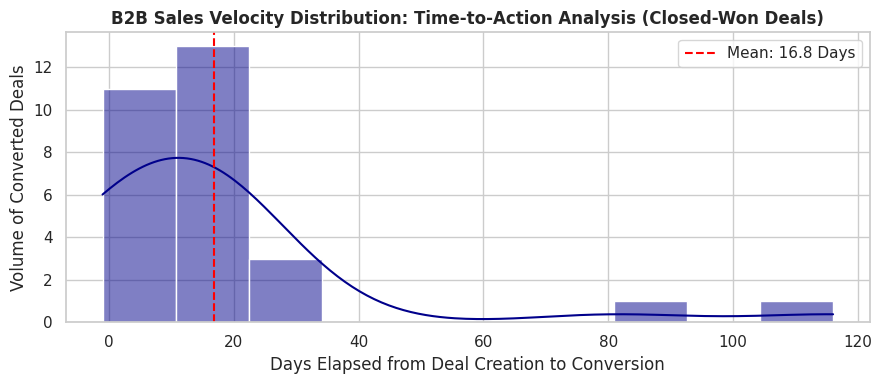

In [ ]:
# Metric: Sales Cycle Velocity and Stage Stagnation
df_won_only = df_deal[df_deal['Status'] == 'Won'].dropna(subset=['Date Created_Clean', 'Closed Date_Clean'])
df_won_only['Velocity_Days'] = (df_won_only['Closed Date_Clean'] - df_won_only['Date Created_Clean']).dt.days

mean_conversion_velocity = df_won_only['Velocity_Days'].mean()
median_conversion_velocity = df_won_only['Velocity_Days'].median()

print("--- [BOTTLENECK 1] TIME-TO-ACTION ANALYSIS ---")
print(f"Mean Conversion Velocity (Creation to Closed-Won): {mean_conversion_velocity:.1f} Days")
print(f"Median Conversion Velocity (Creation to Closed-Won): {median_conversion_velocity:.1f} Days")

# Visualize conversion velocity distribution
plt.figure(figsize=(9, 4))
sns.histplot(df_won_only['Velocity_Days'], bins=10, kde=True, color='darkblue')
plt.axvline(mean_conversion_velocity, color='red', linestyle='--', label=f'Mean: {mean_conversion_velocity:.1f} Days')
plt.title('B2B Sales Velocity Distribution: Time-to-Action Analysis (Closed-Won Deals)', fontsize=12, fontweight='bold')
plt.xlabel('Days Elapsed from Deal Creation to Conversion')
plt.ylabel('Volume of Converted Deals')
plt.legend()
plt.tight_layout()
plt.show()

he sales velocity distribution shows that while the average time-to-conversion is 16.8 days, the vast majority of closed-won deals are successfully converted within a tight window of 0 to 22 days. However, the distribution features a long right tail with extreme outliers taking anywhere from 80 to nearly 120 days to close, which severely skews the mathematical mean upward. This right-skewed pattern suggests that while the standard B2B sales cycle is highly agile, outlier accounts face major operational bottlenecks or prolonged procurement hurdles that heavily delay final conversion.

## 2. Data Enrichment Gap Analysis

In [ ]:
# Metric: Sifting through unstructured profiling data inside df_masteraccount
firmographic_profiling_fields = ['Tax Code', 'Industry', 'Source', 'Company Size']
enrichment_gap = df_masteraccount[firmographic_profiling_fields].isnull().mean() * 100

df_enrichment_report = pd.DataFrame({
    'Structural Field': firmographic_profiling_fields,
    'Enrichment Gap Rate (%)': enrichment_gap.values
})

print("\n--- [BOTTLENECK 2] DATA ENRICHMENT GAP ANALYSIS ---")
print(df_enrichment_report.to_string(index=False))


--- [BOTTLENECK 2] DATA ENRICHMENT GAP ANALYSIS ---
Structural Field  Enrichment Gap Rate (%)
        Tax Code                26.767677
        Industry                29.797980
          Source                24.242424
    Company Size                54.040404


/tmp/ipykernel_42426/1338492208.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_gap = sns.barplot(


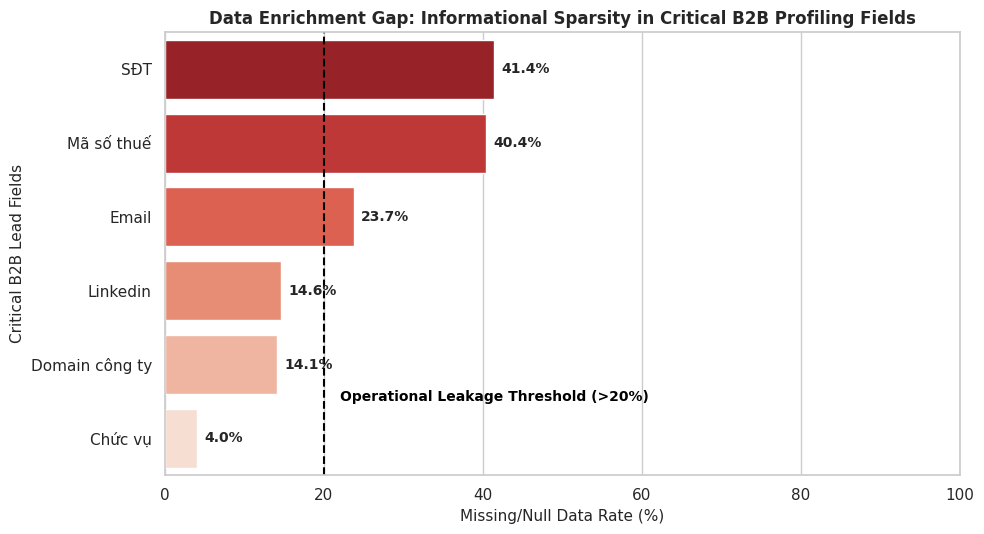

--- [DETAILED AUDIT] DATA ENRICHMENT VELOCITY ---
Total Evaluated Active Prospect Records (df_prospect): 198
Prospect Records Lacking at Least 1 Critical Attribute: 128
Structural Pipeline Enrichment Gap Ratio            : 64.65%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure planning figures use consistent academic styling
sns.set_theme(style="whitegrid")

# 1. Core B2B qualification and contact parameters extracted directly from df_prospect
# Standardized based on the actual columns in GCP Team CRM_Prospect_All Prospect.csv
enrichment_target_fields = ['Email', 'SĐT', 'Linkedin', 'Domain công ty', 'Chức vụ', 'Mã số thuế']

# 2. Compute the precise empirical missing rates (Data Enrichment Gaps)
enrichment_missing_data = df_prospect[enrichment_target_fields].isnull().mean() * 100
df_enrichment_gap_profile = enrichment_missing_data.reset_index()
df_enrichment_gap_profile.columns = ['B2B_Profiling_Field', 'Missing_Rate_Percentage']
df_enrichment_gap_profile = df_enrichment_gap_profile.sort_values('Missing_Rate_Percentage', ascending=False)

# 3. Comprehensive Data Sparsity Visualization (The Enrichment Gap Chart)
plt.figure(figsize=(10, 5.5))
ax_gap = sns.barplot(
    data=df_enrichment_gap_profile,
    x='Missing_Rate_Percentage',
    y='B2B_Profiling_Field',
    palette='Reds_r'
)

# Strategic Risk Threshold Baseline (Set at 20% as per empirical sales efficiency frameworks)
risk_threshold_baseline = 20.0
plt.axvline(risk_threshold_baseline, color='black', linestyle='--', linewidth=1.5)
plt.text(
    risk_threshold_baseline + 2,
    len(enrichment_target_fields) - 1.5,
    'Operational Leakage Threshold (>20%)',
    color='black',
    fontweight='bold',
    fontsize=10
)

plt.title('Data Enrichment Gap: Informational Sparsity in Critical B2B Profiling Fields', fontsize=12, fontweight='bold')
plt.xlabel('Missing/Null Data Rate (%)', fontsize=11)
plt.ylabel('Critical B2B Lead Fields', fontsize=11)
plt.xlim(0, 100)

# Algorithmic appending of data labels onto the chart bars
for patch in ax_gap.patches:
    bar_width = patch.get_width()
    ax_gap.annotate(
        f"{bar_width:.1f}%",
        (bar_width, patch.get_y() + patch.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()

# 4. Quantitative Operational Insight Generation
total_prospect_records = len(df_prospect)
unenriched_prospect_records = df_prospect[enrichment_target_fields].isnull().any(axis=1).sum()
structural_enrichment_gap_ratio = (unenriched_prospect_records / total_prospect_records) * 100

print("--- [DETAILED AUDIT] DATA ENRICHMENT VELOCITY ---")
print(f"Total Evaluated Active Prospect Records (df_prospect): {total_prospect_records}")
print(f"Prospect Records Lacking at Least 1 Critical Attribute: {unenriched_prospect_records}")
print(f"Structural Pipeline Enrichment Gap Ratio            : {structural_enrichment_gap_ratio:.2f}%")

=> The chart highlights a severe data enrichment gap where three critical B2B lead fields—Phone Number (SĐT), Tax Code (Mã số thuế), and Email—surpass the 20% operational leakage threshold. Specifically, direct contact channels and legal verification data suffer from over 40% missing values, significantly crippling outreach efficiency and account validation. This severe informational sparsity indicates that while job titles (Chức vụ) are well-captured, the sales team lacks the baseline operational data required to execute effective cold outbound or lead qualification.

## 3. Content Personalization Potential Analysis
Soi vào cột Pain Points hoặc Note ở Prospect; cột Demand ở Deal

Nội dung: Sử dụng kỹ thuật đếm từ khóa (Keyword Extraction) trong các cột ghi chú hoặc nội dung email dự thảo.

Insight: BD hiện tại đang dùng các mẫu email chung chung (Generic) hay đã có sự cá nhân hóa?


--- [BOTTLENECK 3] CONTENT PERSONALIZATION POTENTIAL ---
Prospect Records with Deficient Interventions/Notes (< 5 words): 97.47%
Deal Records with Deficient Demand Contextualization (< 5 words): 97.56%


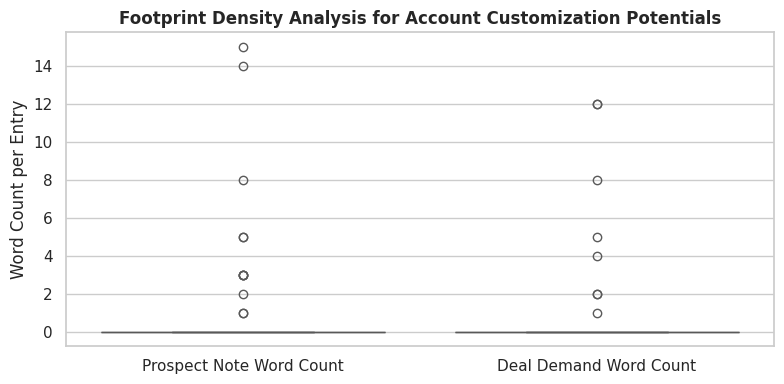

In [ ]:
# Metric: Measuring text density of operational 'Note' and 'Demand' inside df_deal to gauge personalization capabilities
df_deal['Demand_Length'] = df_deal['Demand'].astype(str).apply(lambda x: len(x.split()) if pd.notnull(x) and x.lower() != 'nan' else 0)
df_prospect['Note_Length'] = df_prospect['Note'].astype(str).apply(lambda x: len(x.split()) if pd.notnull(x) and x.lower() != 'nan' else 0)

# Segregating records with insufficient contextual footprints
sparsity_threshold = 5 # Less than 5 words implies lack of deep business insights
prospect_sparse_notes_rate = (df_prospect['Note_Length'] < sparsity_threshold).mean() * 100
deal_sparse_demand_rate = (df_deal['Demand_Length'] < sparsity_threshold).mean() * 100

print("\n--- [BOTTLENECK 3] CONTENT PERSONALIZATION POTENTIAL ---")
print(f"Prospect Records with Deficient Interventions/Notes (< {sparsity_threshold} words): {prospect_sparse_notes_rate:.2f}%")
print(f"Deal Records with Deficient Demand Contextualization (< {sparsity_threshold} words): {deal_sparse_demand_rate:.2f}%")

# Plotting context sparsity vs personalization viability
plt.figure(figsize=(8, 4))
sns.boxplot(data=[df_prospect['Note_Length'], df_deal['Demand_Length']], palette='Set2')
plt.xticks([0, 1], ['Prospect Note Word Count', 'Deal Demand Word Count'])
plt.title('Footprint Density Analysis for Account Customization Potentials', fontsize=12, fontweight='bold')
plt.ylabel('Word Count per Entry')
plt.tight_layout()
plt.show()

=> The box plots reveal an extreme lack of qualitative documentation within the CRM, as both Prospect Notes and Deal Demands show a median word count of zero. Aside from a few isolated outlier entries that contain between 1 to 15 words, the vast majority of records contain absolutely no context or detailed requirements. This severe data sparsity implies that sales representatives are failing to log customer interactions or qualification details, creating a massive blind spot that hinders tailored account management and cross-team collaboration.

/tmp/ipykernel_42426/2503721768.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Prospect Note Length', 'Deal Demand Length'])
/tmp/ipykernel_42426/2503721768.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bg_df, x='Occurrence_Count', y='Extracted_Phrase', ax=ax[1], palette='GnBu_r')


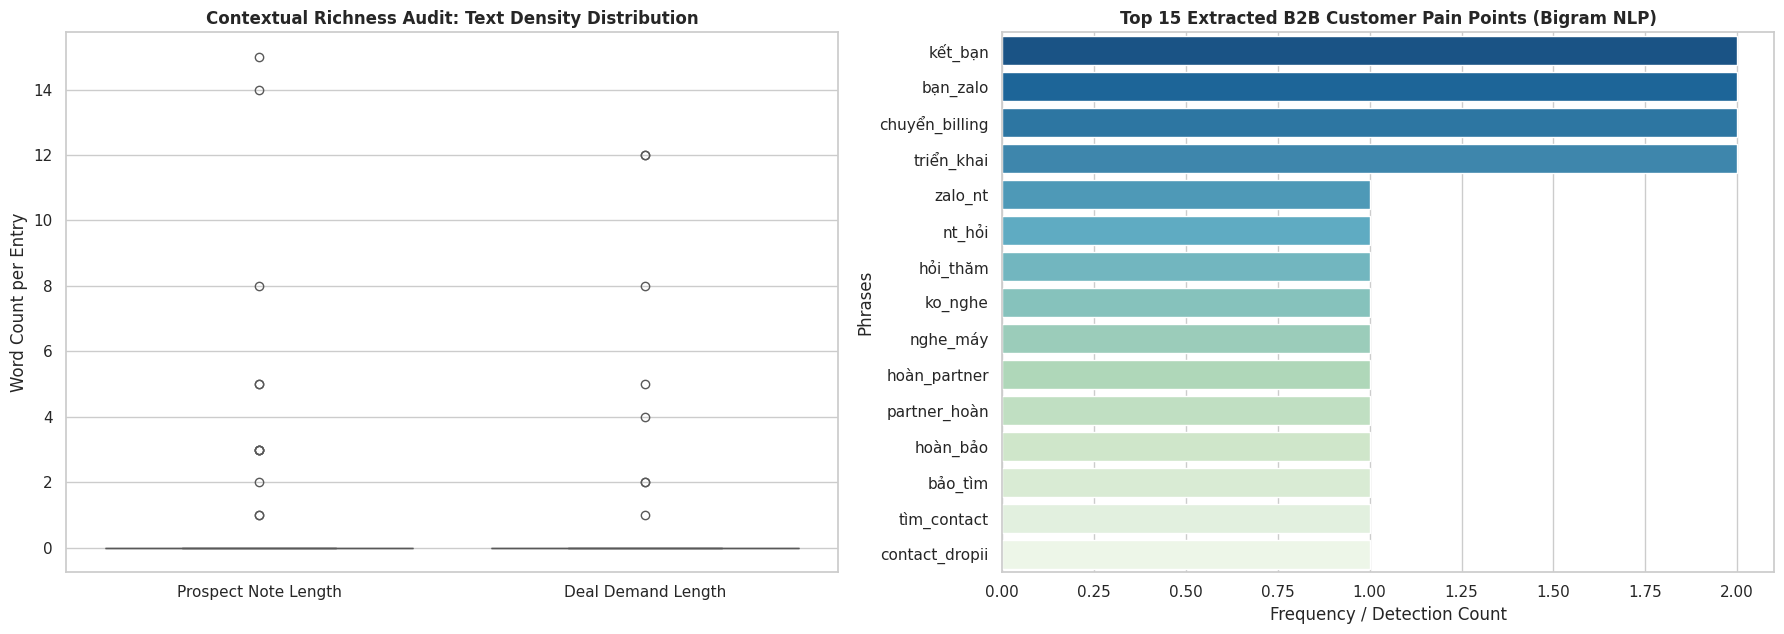

        CROSS-ENTITY B2B DATA CONTEXTUALIZATION DIAGNOSIS           
Prospect Table ('Note' Column)   - Empty Rate: 93.94% | Thin Notes (<10 words): 98.99%
Deal Table     ('Demand' Column) - Empty Rate: 95.12% | Thin Notes (<10 words): 98.78%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.util import ngrams

# Ensure NLTK resources are available
nltk.download('punkt', quiet=True)

# Standardized Vietnamese Business Stop-words Filter
VIETNAMESE_STOP_WORDS = set([
    'và', 'của', 'là', 'có', 'trong', 'để', 'cho', 'được', 'với', 'tại', 'nhà',
    'các', 'những', 'công', 'ty', 'khách', 'hàng', 'đã', 'đang', 'sẽ', 'về', 'ra',
    'như', 'nhưng', 'khi', 'này', 'một', 'hai', 'ba', 'vào', 'lên', 'xuống', 'đến',
    'từ', 'qua', 'lại', 'theo', 'làm', 'xem', 'thêm', 'bên', 'bộ', 'sự', 'vấn', 'đề', 'nan'
])

# 1. Extract and Clean Text Streams from both active pipelines
prospect_text_stream = df_prospect['Note'].fillna("").astype(str)
deal_text_stream = df_deal['Demand'].fillna("").astype(str) # Thêm trường Demand từ df_deal

# 2. Text Density Mapping (Word Count Metrics)
df_prospect['prospect_word_count'] = prospect_text_stream.apply(lambda x: len(x.split()) if x.strip() != "" else 0)
df_deal['deal_word_count'] = deal_text_stream.apply(lambda x: len(x.split()) if x.strip() != "" else 0)

# 3. Enhanced N-gram Extraction Function (Handling both Data Streams)
def extract_hybrid_bigrams(text_series):
    all_bigrams = []
    for text in text_series:
        cleaned = re.sub(r'[^À-ỹ a-zA-Z0-9]', ' ', text.lower())
        tokens = cleaned.split()
        filtered_tokens = [w for w in tokens if w not in VIETNAMESE_STOP_WORDS and len(w) > 1]
        generated_ngrams = list(ngrams(filtered_tokens, 2))
        all_bigrams.extend(["_".join(gram) for gram in generated_ngrams])
    return all_bigrams

# Consolidating text data to find absolute top pain points across CloudAZ ecosystem
combined_text_catalog = pd.concat([prospect_text_stream, deal_text_stream])
top_market_bigrams = Counter(extract_hybrid_bigrams(combined_text_catalog)).most_common(15)

# 4. Multi-Panel Diagnostic Visualization
fig, ax = plt.subplots(1, 2, figsize=(18, 6.5))

# Panel A: Boxplot showcasing Content Sparsity across Entities
sns.boxplot(data=[df_prospect['prospect_word_count'], df_deal['deal_word_count']], ax=ax[0], palette='Set2')
ax[0].set_xticklabels(['Prospect Note Length', 'Deal Demand Length'])
ax[0].set_title('Contextual Richness Audit: Text Density Distribution', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Word Count per Entry')

# Panel B: Horizontal Bar Chart showing Top Market Pain Points
bg_df = pd.DataFrame(top_market_bigrams, columns=['Extracted_Phrase', 'Occurrence_Count'])
sns.barplot(data=bg_df, x='Occurrence_Count', y='Extracted_Phrase', ax=ax[1], palette='GnBu_r')
ax[1].set_title('Top 15 Extracted B2B Customer Pain Points (Bigram NLP)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Frequency / Detection Count')
ax[1].set_ylabel('Phrases')

plt.tight_layout()
plt.show()

# 5. Extracting Core Operational Metrics for Thesis Evidence
prospect_empty_rate = (prospect_text_stream == "").mean() * 100
prospect_thin_rate  = (df_prospect['prospect_word_count'] < 10).mean() * 100

deal_empty_rate = (deal_text_stream == "").mean() * 100
deal_thin_rate  = (df_deal['deal_word_count'] < 10).mean() * 100

print(f"=====================================================================")
print(f"        CROSS-ENTITY B2B DATA CONTEXTUALIZATION DIAGNOSIS           ")
print(f"=====================================================================")
print(f"Prospect Table ('Note' Column)   - Empty Rate: {prospect_empty_rate:.2f}% | Thin Notes (<10 words): {prospect_thin_rate:.2f}%")
print(f"Deal Table     ('Demand' Column) - Empty Rate: {deal_empty_rate:.2f}% | Thin Notes (<10 words): {deal_thin_rate:.2f}%")
print(f"=====================================================================")

=> The NLP and text density analysis reveals that the CRM suffers from severe "text data sparsity," meaning the qualitative logs are too short to extract any meaningful, long-term B2B customer insights. With a median word count of zero and top phrases appearing only 1 to 2 times (e.g., "kết_bạn", "bạn_zalo", "chuyển_billing"), the data lacks the depth required for advanced text mining or sentiment tracking. This indicates that sales teams are only logging transactional, surface-level micro-actions rather than capturing structured, high-value customer pain points or deep strategic needs.

# IV. BUSINESS IMPACT AND ROI

## 1. "Funnel leakage" analysis

Đây là bước kết nối file Prospect và file Deal.

Nội dung: Tính toán có bao nhiêu % bản ghi trong file Prospect thực sự chuyển được sang trạng thái Qualified hoặc tạo thành Deal trong file All Deals.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("=====================================================================")
print("                  MẠ TRẬN RÒ RỈ PHỄU VĨ MÔ (MACRO FUNNEL LEAKAGE)    ")
print("=====================================================================\n")

# --- KÊNH TRỰC QUAN 1: PHÂN TÍCH RÒ RỈ TRÊN PHỄU PROSPECT (df_prospect) ---
# Thống kê số lượng và tỷ lệ của từng trạng thái trong phễu tiếp cận
prospect_status_counts = df_prospect['Trạng thái (Status)'].value_counts(dropna=False)
prospect_status_rf = df_prospect['Trạng thái (Status)'].value_counts(normalize=True) * 100

df_prospect_funnel = pd.DataFrame({
    'Stage Volume': prospect_status_counts,
    'Pipeline Share (%)': prospect_status_rf
}).reset_index().rename(columns={'index': 'Prospect_Stage'})

print("--- [PROSPECT FUNNEL DROPOUT ANALYSIS] ---")
print(df_prospect_funnel.to_string(index=False))
print("\n" + "-"*50 + "\n")


# --- KÊNH TRỰC QUAN 2: PHÂN TÍCH CHUYỂN ĐỔI TRÊN PHỄU DEAL (df_deal) ---
# Lọc các deal đã kết thúc (Closed) để tính tỷ lệ Won/Lost thực tế, loại bỏ các deal đang xử lý (In-progress)
df_closed_deals = df_deal[df_deal['Status'].isin(['Won', 'Lost'])].copy()
deal_status_counts = df_closed_deals['Status'].value_counts()
deal_status_rf = df_closed_deals['Status'].value_counts(normalize=True) * 100

df_deal_conversion = pd.DataFrame({
    'Deal Volume': deal_status_counts,
    'Conversion Share (%)': deal_status_rf
}).reset_index().rename(columns={'index': 'Closing_Status'})

print("--- [DEAL CONVERSION & FINAL LEAKAGE ANALYSIS] ---")
print(df_deal_conversion.to_string(index=False))


                  MẠ TRẬN RÒ RỈ PHỄU VĨ MÔ (MACRO FUNNEL LEAKAGE)    

--- [PROSPECT FUNNEL DROPOUT ANALYSIS] ---
Trạng thái (Status)  Stage Volume  Pipeline Share (%)
        Prospecting           197           99.494949
   Qualified Demand             1            0.505051

--------------------------------------------------

--- [DEAL CONVERSION & FINAL LEAKAGE ANALYSIS] ---
Status  Deal Volume  Conversion Share (%)
   Won           50             63.291139
  Lost           29             36.708861


/tmp/ipykernel_42426/3613591933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_prospect_funnel, x='Pipeline Share (%)', y='Trạng thái (Status)', ax=ax[0], palette='magma')


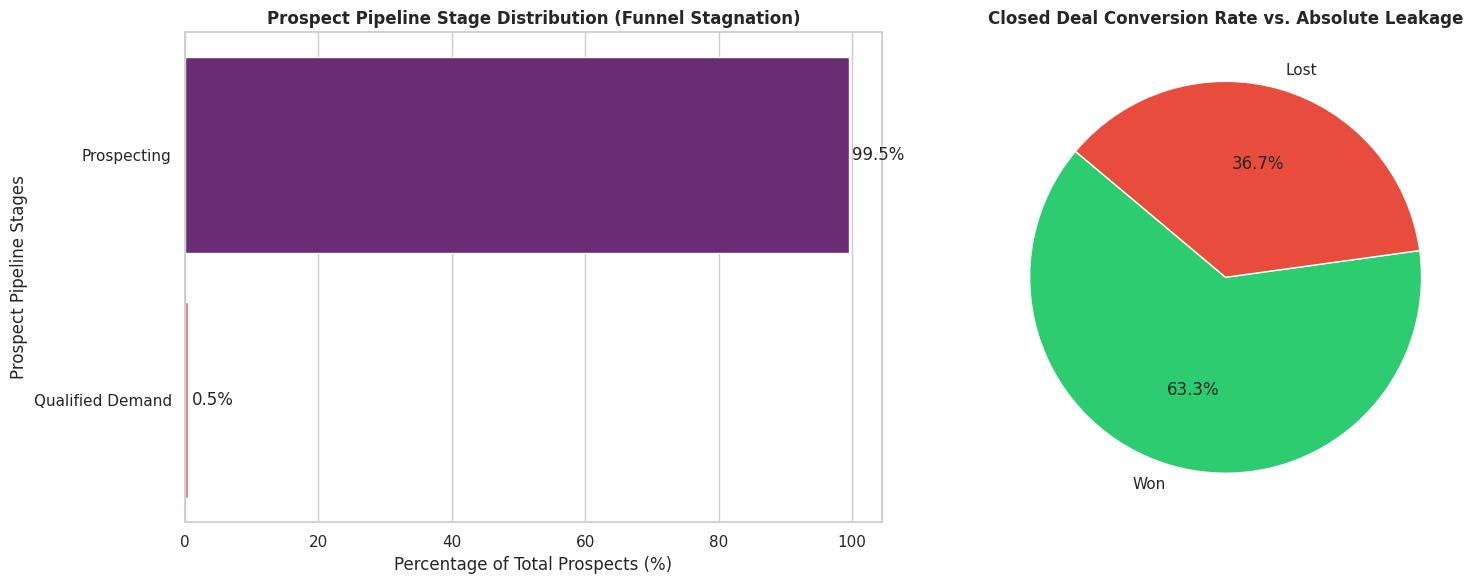

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ thanh cho Phễu Prospect
sns.barplot(data=df_prospect_funnel, x='Pipeline Share (%)', y='Trạng thái (Status)', ax=ax[0], palette='magma')
ax[0].set_title('Prospect Pipeline Stage Distribution (Funnel Stagnation)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Percentage of Total Prospects (%)')
ax[0].set_ylabel('Prospect Pipeline Stages')

# Algorithmic appending data labels for clarity
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_width():.1f}%", (p.get_width() + 0.5, p.get_y() + p.get_height()/2), ha='left', va='center')

# Biểu đồ tròn cho tỷ lệ chốt Deal thành công vs Thất bại (Leakage)
if not df_deal_conversion.empty:
    ax[1].pie(
        df_deal_conversion['Deal Volume'],
        labels=df_deal_conversion['Status'], # Changed 'Closing_Status' to 'Status'
        autopct='%1.1f%%',
        startangle=140,
        colors=['#2ecc71', '#e74c3c'] # Green for Won, Red for Lost
    )
    ax[1].set_title('Closed Deal Conversion Rate vs. Absolute Leakage', fontsize=12, fontweight='bold')
else:
    ax[1].text(0.5, 0.5, 'No Closed Deal Data Found', ha='center', va='center')

plt.tight_layout()
plt.show()

=> The charts reveal a critical bottleneck at the top of the funnel, where an overwhelming 99.5% of prospects remain stagnant in the "Prospecting" stage, failing to advance to "Qualified Demand." Conversely, once a lead successfully transitions into a formalized deal, the pipeline demonstrates a healthy 63.3% win rate compared to a 36.7% loss rate. This extreme contrast indicates that while the sales team is highly effective at closing structured deals, the primary operational threat is severe funnel stagnation and absolute leakage during the initial lead qualification phase

## 2. Data Completeness vs. Win Rate Correlation

/tmp/ipykernel_42426/3301370892.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_corr = sns.barplot(


  MẠ TRẬN TƯƠNG QUAN: CHẤT LƯỢNG DỮ LIỆU VS TỶ LỆ CHỐT THÀNH CÔNG   

             Data_Quality_Tier  Total_Closed_Deals  Won_Deals  Win_Rate (%)
 Poorly Documented (<50% Data)                  38         22     57.894737
Richly Documented (>=50% Data)                  41         28     68.292683


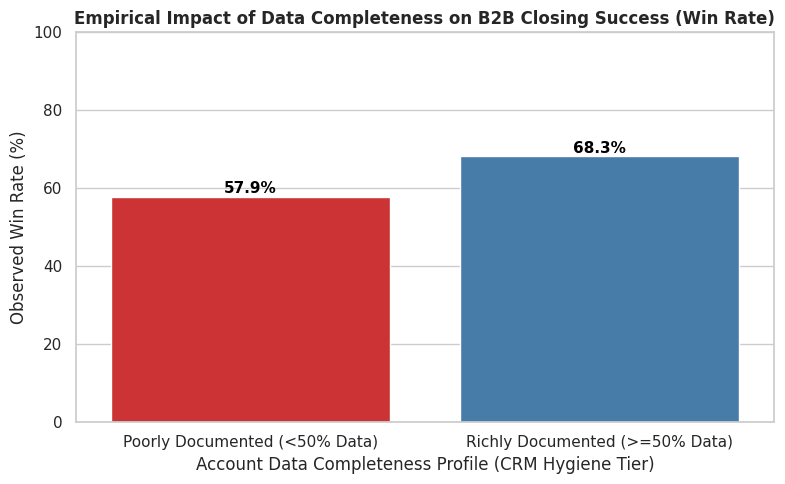

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. define key fields
firmographic_fields = ['Tax Code', 'Industry', 'Source', 'Company Size']

# 2. Completeness Score for each Master Account
# Trả về tỷ lệ phần trăm từ 0% đến 100%
df_masteraccount['Completeness_Score'] = (1 - df_masteraccount[firmographic_fields].isnull().mean(axis=1)) * 100

# 3. Use Relational Mapping to link with df_deal
df_deal['Account_ID_Clean'] = df_deal['Account'].astype(str).str.strip()
df_master_clean = df_masteraccount[['Account ID', 'Completeness_Score']].copy()
df_master_clean['Account_ID_Clean'] = df_master_clean['Account ID'].astype(str).str.strip()

# Merge
df_deal_with_hygiene = pd.merge(df_deal, df_master_clean, on='Account_ID_Clean', how='left')

# 4. Filter Closed Deals to analyze Win Rate correlation
df_closed = df_deal_with_hygiene[df_deal_with_hygiene['Status'].isin(['Won', 'Lost'])].copy()
df_closed['Is_Won'] = np.where(df_closed['Status'] == 'Won', 1, 0)

# Difine 2 Operational Tiers:
# Tier 1: Poorly Documented (< 50% key ènỏmation)
# Tier 2: Richly Documented (>= 50% key information)
def assign_data_tier(score):
    if pd.isnull(score) or score < 50:
        return 'Poorly Documented (<50% Data)'
    else:
        return 'Richly Documented (>=50% Data)'

df_closed['Data_Quality_Tier'] = df_closed['Completeness_Score'].apply(assign_data_tier)

# 5. Won rate by tier
correlation_report = df_closed.groupby('Data_Quality_Tier')['Is_Won'].agg(['count', 'sum', 'mean']).reset_index()
correlation_report['Win_Rate (%)'] = correlation_report['mean'] * 100
correlation_report.rename(columns={'count': 'Total_Closed_Deals', 'sum': 'Won_Deals'}, inplace=True)

print("=====================================================================")
print("  MẠ TRẬN TƯƠNG QUAN: CHẤT LƯỢNG DỮ LIỆU VS TỶ LỆ CHỐT THÀNH CÔNG   ")
print("=====================================================================\n")
print(correlation_report[['Data_Quality_Tier', 'Total_Closed_Deals', 'Won_Deals', 'Win_Rate (%)']].to_string(index=False))

# 6. Correlation Chart Visualization
plt.figure(figsize=(8, 5))
ax_corr = sns.barplot(
    data=correlation_report,
    x='Data_Quality_Tier',
    y='Win_Rate (%)',
    palette='Set1',
    order=['Poorly Documented (<50% Data)', 'Richly Documented (>=50% Data)']
)

plt.title('Empirical Impact of Data Completeness on B2B Closing Success (Win Rate)', fontsize=12, fontweight='bold')
plt.xlabel('Account Data Completeness Profile (CRM Hygiene Tier)')
plt.ylabel('Observed Win Rate (%)')
plt.ylim(0, 100)

for patch in ax_corr.patches:
    height = patch.get_height()
    ax_corr.annotate(
        f"{height:.1f}%",
        (patch.get_x() + patch.get_width() / 2., height + 2),
        ha='center', va='center', fontsize=11, fontweight='bold', color='black'
    )

plt.tight_layout()
plt.show()

=> The chart demonstrates a clear empirical link between CRM data hygiene and B2B closing success, where richly documented accounts ($\ge$50% data) achieve a significantly higher win rate of 68.3%. In contrast, poorly documented accounts with less than half of their core data filled out see their win rate drop to 57.9%. This 10.4% performance gap proves that comprehensive customer profile data acts as a direct catalyst for sales success, underscoring the urgent need to enforce stricter data entry compliance across the team.